# 02 — Feature Extraction & Train/Val/Test Split
**Indoor WiFi Fingerprinting Localization**

Fingerprint matrix → filtered, encoded, split dataset ready for model training.

### Steps
1. Load preprocessed fingerprints
2. Filter low-coverage APs (too sparse to be informative)
3. Encode location labels → integer class IDs
4. Stratified train / val / test split (70 / 15 / 15)
5. Optionally normalize RSSI (StandardScaler)
6. Save splits + metadata

In [1]:
!pip install scikit-learn

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')

In [4]:
ROOT      = Path('../../')
DATA_PROC = ROOT / 'Data' / '02_Processed_Wifi_Daytime'
SPLITS    = DATA_PROC / 'splits'
SPLITS.mkdir(parents=True, exist_ok=True)

RSSI_MISSING      = -100   # must match preprocessing
AP_MIN_COVERAGE   = 5.0    # % — drop APs seen in fewer than this % of scans
VAL_SIZE          = 0.15
TEST_SIZE         = 0.15
RANDOM_SEED       = 42

print(f'AP coverage threshold : {AP_MIN_COVERAGE}%')
print(f'Split  : {100*(1-VAL_SIZE-TEST_SIZE):.0f} / {100*VAL_SIZE:.0f} / {100*TEST_SIZE:.0f}  (train/val/test)')

AP coverage threshold : 5.0%
Split  : 70 / 15 / 15  (train/val/test)


## 1. Load preprocessed fingerprints

In [5]:
fingerprints = pd.read_csv(DATA_PROC / 'fingerprints.csv')
ap_coverage  = pd.read_csv(DATA_PROC / 'ap_coverage.csv', index_col=0)['coverage_pct']

META_COLS = ['Timestamp', 'Location_Label', 'Activity_Label']
all_bssids = [c for c in fingerprints.columns if c not in META_COLS]

print(f'Fingerprints shape : {fingerprints.shape}')
print(f'Locations          : {fingerprints["Location_Label"].nunique()}')
print(f'All BSSIDs         : {len(all_bssids)}')
fingerprints.head(3)

Fingerprints shape : (455, 185)
Locations          : 19
All BSSIDs         : 182


,Timestamp,Location_Label,Activity_Label,00:27:e3:29:d2:a0,00:27:e3:29:d2:af,00:27:e3:29:d2:e0,00:27:e3:29:db:e0,00:27:e3:29:dc:00,00:27:e3:29:e8:80,00:27:e3:29:e8:8f,...,cc:db:93:65:2d:20,cc:db:93:65:30:0f,cc:db:93:65:52:0f,da:b3:2f:cd:22:39,e2:bb:9e:59:1c:fd,ee:91:61:62:68:1c,ee:91:61:62:97:64,f8:da:0c:42:3a:06,fc:01:7c:92:66:80,fe:bf:77:35:66:79
0,2026-03-16 14:15:50.985830,Stairs_Opp_DLT8_2,STATIONARY,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-85.0,-100.0,-100.0
1,2026-03-16 14:15:53.300330,Stairs_Opp_DLT8_2,STATIONARY,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0
2,2026-03-16 14:15:57.319555,Stairs_Opp_DLT8_2,STATIONARY,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,...,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0,-100.0


## 2. AP filtering — remove sparse APs

An AP that is almost never detected carries no discriminative information and just adds noise.

APs kept  (>= 5.0% coverage): 116
APs dropped              : 66


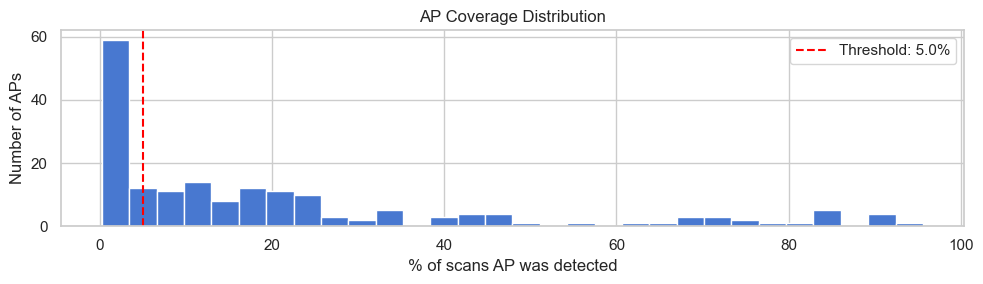

In [6]:
selected_bssids = ap_coverage[ap_coverage >= AP_MIN_COVERAGE].index.tolist()
dropped_bssids  = ap_coverage[ap_coverage <  AP_MIN_COVERAGE].index.tolist()

print(f'APs kept  (>= {AP_MIN_COVERAGE}% coverage): {len(selected_bssids)}')
print(f'APs dropped              : {len(dropped_bssids)}')

# Coverage histogram
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(ap_coverage.values, bins=30, edgecolor='white')
ax.axvline(AP_MIN_COVERAGE, color='red', linestyle='--',
           label=f'Threshold: {AP_MIN_COVERAGE}%')
ax.set_title('AP Coverage Distribution')
ax.set_xlabel('% of scans AP was detected')
ax.set_ylabel('Number of APs')
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PROC / 'ap_coverage_hist.png', dpi=100)
plt.show()

In [7]:
# Apply filter
X_df = fingerprints[selected_bssids].copy()
print(f'Feature matrix shape: {X_df.shape}  (scans × APs)')

Feature matrix shape: (455, 116)  (scans × APs)


## 3. Per-AP RSSI statistics & discriminability

In [8]:
# RSSI variance per AP — higher variance = more discriminative
rssi_var = X_df.replace(RSSI_MISSING, np.nan).var()
rssi_mean = X_df.replace(RSSI_MISSING, np.nan).mean()

ap_stats = pd.DataFrame({
    'coverage_pct': ap_coverage[selected_bssids],
    'rssi_mean'   : rssi_mean,
    'rssi_std'    : X_df.replace(RSSI_MISSING, np.nan).std(),
    'rssi_var'    : rssi_var
}).sort_values('rssi_var', ascending=False)

print('Top 15 most variable APs (best candidates for localization):')
print(ap_stats.head(15).to_string())

Top 15 most variable APs (best candidates for localization):
                   coverage_pct  rssi_mean   rssi_std    rssi_var
08:4f:a9:2d:8a:a0     18.461538 -56.785714  17.310121  299.640275
08:4f:a9:2d:8a:4e     84.395604 -71.890625  17.258699  297.862680
08:4f:a9:2d:8a:4f     82.417582 -71.736000  17.237943  297.146695
08:4f:a9:2d:8a:40     20.439560 -62.827957  17.118909  293.057036
08:4f:a9:2d:8a:41     73.626374 -60.232836  16.793198  282.011493
08:4f:a9:39:68:2e     84.835165 -70.551813  16.556983  274.133672
08:4f:a9:39:68:2f     83.516484 -70.531579  16.556023  274.101903
08:4f:a9:2d:8a:ae     73.186813 -69.615616  16.273528  264.827707
08:4f:a9:2d:8a:af     69.670330 -68.917981  16.188942  262.081859
08:4f:a9:2d:8a:a1     78.021978 -57.594366  15.918009  253.383019
08:4f:a9:39:68:21     71.208791 -61.873457  14.763755  217.968457
08:4f:a9:10:4b:8e     92.087912 -69.408115  13.621262  185.538786
70:ea:1a:22:8f:ee     90.989011 -67.154589  13.390223  179.298078
70:ea:1a:22:8f:

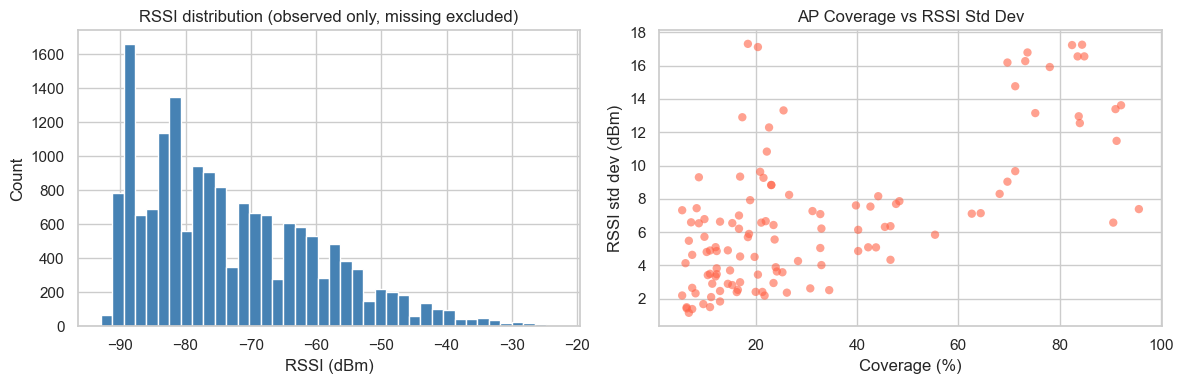

In [9]:
# RSSI distribution for observed values only
observed_rssi = X_df.values.flatten()
observed_rssi = observed_rssi[observed_rssi > RSSI_MISSING]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(observed_rssi, bins=40, edgecolor='white', color='steelblue')
axes[0].set_title('RSSI distribution (observed only, missing excluded)')
axes[0].set_xlabel('RSSI (dBm)')
axes[0].set_ylabel('Count')

axes[1].scatter(ap_stats['coverage_pct'], ap_stats['rssi_std'],
                alpha=0.6, edgecolors='none', color='tomato')
axes[1].set_title('AP Coverage vs RSSI Std Dev')
axes[1].set_xlabel('Coverage (%)')
axes[1].set_ylabel('RSSI std dev (dBm)')

plt.tight_layout()
plt.savefig(DATA_PROC / 'feature_stats.png', dpi=100)
plt.show()

## 4. Encode location labels

In [10]:
le = LabelEncoder()
y = le.fit_transform(fingerprints['Location_Label'])

label_map = {int(i): str(name) for i, name in enumerate(le.classes_)}
print(f'Classes ({len(le.classes_)}):')
for idx, name in label_map.items():
    count = (y == idx).sum()
    print(f'  {idx:2d}  {name:<55}  ({count} scans)')

Classes (19):
   0  Btw_DLT_8_and_F_Chamber_Entrance                         (24 scans)
   1  Btw_Stairs_and_DLT7                                      (24 scans)
   2  D-151/1 Computation Lab                                  (24 scans)
   3  D-151/2_D-153/1                                          (24 scans)
   4  D-152                                                    (24 scans)
   5  D-153/2 SMART Space                                      (24 scans)
   6  D-154                                                    (23 scans)
   7  D-157,158,159,160                                        (24 scans)
   8  D-161,162,163,164                                        (24 scans)
   9  D-165,166,167,168                                        (24 scans)
  10  D-169, CAIR                                              (24 scans)
  11  F_Chamber_Entrance_2                                     (24 scans)
  12  F_Chamber_Entrance_Opp_DLT8                              (24 scans)
  13  Garden_Btw_DLT7_DL

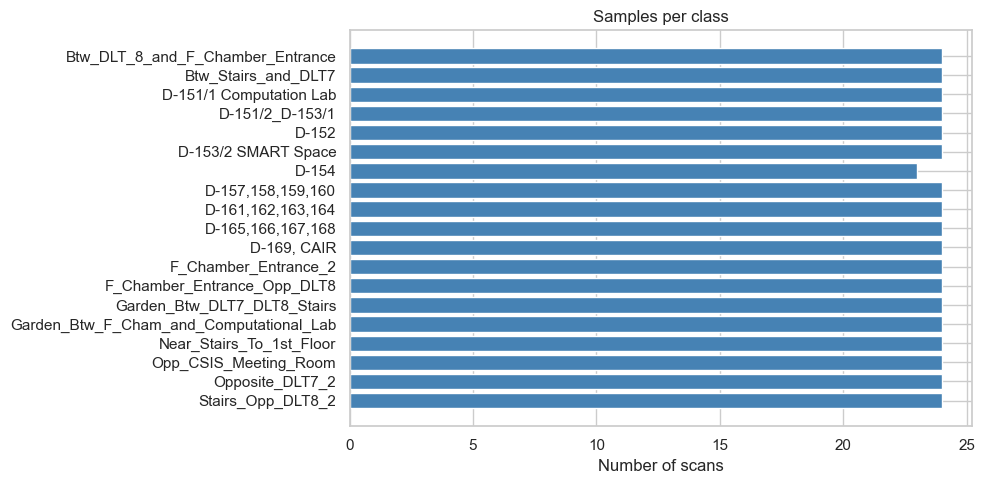

In [11]:
# Class balance plot
fig, ax = plt.subplots(figsize=(10, 5))
class_counts = pd.Series(y).value_counts().sort_index()
ax.barh([label_map[i] for i in class_counts.index], class_counts.values, color='steelblue')
ax.set_title('Samples per class')
ax.set_xlabel('Number of scans')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(DATA_PROC / 'class_balance.png', dpi=100)
plt.show()

## 5. Train / Validation / Test split

Stratified by location to ensure each split has representative samples from every location.

**Why orientation is not a problem here:**
Each scan was collected at one of 8 orientations (0°–315° in 45° steps).
By including all orientations in training and splitting randomly, the model learns
to be orientation-robust by exposure rather than explicit modelling.

In [12]:
X = X_df.values.astype(np.float32)

# First: carve out test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_SEED
)

# Then: split remainder into train / val
val_relative = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=val_relative,
    stratify=y_temp,
    random_state=RANDOM_SEED
)

print(f'Train : {X_train.shape[0]} samples  ({100*X_train.shape[0]/len(X):.1f}%)')
print(f'Val   : {X_val.shape[0]} samples  ({100*X_val.shape[0]/len(X):.1f}%)')
print(f'Test  : {X_test.shape[0]} samples  ({100*X_test.shape[0]/len(X):.1f}%)')
print(f'Features: {X_train.shape[1]}')

Train : 317 samples  (69.7%)
Val   : 69 samples  (15.2%)
Test  : 69 samples  (15.2%)
Features: 116


In [13]:
# Verify stratification — each class should be roughly proportional in every split
def class_dist(y_split, name):
    counts = np.bincount(y_split, minlength=len(le.classes_))
    return pd.Series(counts / counts.sum() * 100, 
                     index=[label_map[i] for i in range(len(le.classes_))],
                     name=name)

dist_df = pd.concat([
    class_dist(y_train, 'Train %'),
    class_dist(y_val,   'Val %'),
    class_dist(y_test,  'Test %'),
], axis=1)

print('Class distribution per split (%):')
print(dist_df.round(1).to_string())

Class distribution per split (%):
                                         Train %  Val %  Test %
Btw_DLT_8_and_F_Chamber_Entrance             5.4    5.8     4.3
Btw_Stairs_and_DLT7                          5.4    5.8     4.3
D-151/1 Computation Lab                      5.4    4.3     5.8
D-151/2_D-153/1                              5.4    5.8     4.3
D-152                                        5.4    4.3     5.8
D-153/2 SMART Space                          5.4    5.8     4.3
D-154                                        5.4    4.3     4.3
D-157,158,159,160                            5.0    5.8     5.8
D-161,162,163,164                            5.0    5.8     5.8
D-165,166,167,168                            5.4    5.8     4.3
D-169, CAIR                                  5.4    4.3     5.8
F_Chamber_Entrance_2                         5.0    5.8     5.8
F_Chamber_Entrance_Opp_DLT8                  5.0    5.8     5.8
Garden_Btw_DLT7_DLT8_Stairs                  5.4    4.3     5.8
Garden

## 6. Optional: Normalize RSSI values

Fit scaler on **train only**, apply to all splits.
Saves both raw and normalized versions — tree-based models prefer raw, distance-based/linear models prefer normalized.

In [14]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print('Scaler fit on training set.')
print(f'  Train mean (post-scale): {X_train_sc.mean():.4f}  std: {X_train_sc.std():.4f}')
print(f'  Val   mean (post-scale): {X_val_sc.mean():.4f}  std: {X_val_sc.std():.4f}')

Scaler fit on training set.
  Train mean (post-scale): 0.0000  std: 1.0000
  Val   mean (post-scale): -0.0135  std: 0.9811


## 7. Save everything

In [15]:
import joblib

def save_split(prefix, X_raw, X_scaled, y_arr):
    np.save(SPLITS / f'{prefix}_X.npy',        X_raw)
    np.save(SPLITS / f'{prefix}_X_scaled.npy', X_scaled)
    np.save(SPLITS / f'{prefix}_y.npy',        y_arr)

save_split('train', X_train, X_train_sc, y_train)
save_split('val',   X_val,   X_val_sc,   y_val)
save_split('test',  X_test,  X_test_sc,  y_test)

# Save scaler
joblib.dump(scaler, SPLITS / 'scaler.joblib')

# Save label encoder + mapping
joblib.dump(le,     SPLITS / 'label_encoder.joblib')
with open(SPLITS / 'label_map.json', 'w') as f:
    json.dump(label_map, f, indent=2)

# Save selected feature (BSSID) names
with open(SPLITS / 'feature_bssids.json', 'w') as f:
    json.dump(selected_bssids, f, indent=2)

# Save AP stats for reference
ap_stats.to_csv(SPLITS / 'ap_stats.csv')

print('Saved to:', SPLITS.resolve())
for p in sorted(SPLITS.iterdir()):
    print(f'  {p.name}')

Saved to: D:\Source_Codes\01_Ongoing\03_Indoor_Localization\Android\Data\02_Processed_Wifi_Daytime\splits
  ap_stats.csv
  feature_bssids.json
  label_encoder.joblib
  label_map.json
  scaler.joblib
  test_X.npy
  test_X_scaled.npy
  test_y.npy
  train_X.npy
  train_X_scaled.npy
  train_y.npy
  val_X.npy
  val_X_scaled.npy
  val_y.npy


## 8. Summary

In [18]:
print('FEATURE EXTRACTION SUMMARY\n\n')

print(f'  Features (BSSIDs selected)  : {len(selected_bssids)}')
print(f'  AP coverage threshold       : {AP_MIN_COVERAGE}%')
print(f'  Classes (locations)         : {len(le.classes_)}')
print(f'  Total samples               : {len(X)}')
print(f'  Train samples               : {len(X_train)}')
print(f'  Val   samples               : {len(X_val)}')
print(f'  Test  samples               : {len(X_test)}')

print()
print('Files in splits/:')
print('  train_X.npy          — raw RSSI features')
print('  train_X_scaled.npy   — normalized features')
print('  train_y.npy          — integer labels')
print('  (same for val_ and test_)')
print('  scaler.joblib        — StandardScaler (fit on train)')
print('  label_encoder.joblib — LabelEncoder')
print('  label_map.json       — {int: location_name}')
print('  feature_bssids.json  — ordered list of BSSID feature columns')
print()
print('Next: 03_Model_Training.ipynb')

FEATURE EXTRACTION SUMMARY


  Features (BSSIDs selected)  : 116
  AP coverage threshold       : 5.0%
  Classes (locations)         : 19
  Total samples               : 455
  Train samples               : 317
  Val   samples               : 69
  Test  samples               : 69

Files in splits/:
  train_X.npy          — raw RSSI features
  train_X_scaled.npy   — normalized features
  train_y.npy          — integer labels
  (same for val_ and test_)
  scaler.joblib        — StandardScaler (fit on train)
  label_encoder.joblib — LabelEncoder
  label_map.json       — {int: location_name}
  feature_bssids.json  — ordered list of BSSID feature columns

Next: 03_Model_Training.ipynb
